In [4]:
import pandas as pd

# Carregando o dataset
df = pd.read_csv('/content/data.csv')

# Exibindo a lista de colunas
print('Colunas encontradas no dataset:')
print(df.columns.tolist())

# Exibindo as primeiras linhas para contexto
display(df.head())

Colunas encontradas no dataset:
['Income', 'Age', 'Dependents', 'Occupation', 'City_Tier', 'Rent', 'Loan_Repayment', 'Insurance', 'Groceries', 'Transport', 'Eating_Out', 'Entertainment', 'Utilities', 'Healthcare', 'Education', 'Miscellaneous', 'Desired_Savings_Percentage', 'Desired_Savings', 'Disposable_Income', 'Potential_Savings_Groceries', 'Potential_Savings_Transport', 'Potential_Savings_Eating_Out', 'Potential_Savings_Entertainment', 'Potential_Savings_Utilities', 'Potential_Savings_Healthcare', 'Potential_Savings_Education', 'Potential_Savings_Miscellaneous']


,Income,Age,Dependents,Occupation,City_Tier,Rent,Loan_Repayment,Insurance,Groceries,Transport,...,Desired_Savings,Disposable_Income,Potential_Savings_Groceries,Potential_Savings_Transport,Potential_Savings_Eating_Out,Potential_Savings_Entertainment,Potential_Savings_Utilities,Potential_Savings_Healthcare,Potential_Savings_Education,Potential_Savings_Miscellaneous
0,44637.249636,49,0,Self_Employed,Tier_1,13391.174891,0.000000,2206.490129,6658.768341,2636.970696,...,6200.537192,11265.627707,1685.696222,328.895281,465.769172,195.151320,678.292859,67.682471,0.000000,85.735517
1,26858.596592,34,2,Retired,Tier_2,5371.719318,0.000000,869.522617,2818.444460,1543.018778,...,1923.176434,9676.818733,540.306561,119.347139,141.866089,234.131168,286.668408,6.603212,56.306874,97.388606
2,50367.605084,35,1,Student,Tier_3,7555.140763,4612.103386,2201.800050,6313.222081,3221.396403,...,7050.360422,13891.450624,1466.073984,473.549752,410.857129,459.965256,488.383423,7.290892,106.653597,138.542422
3,101455.600247,21,0,Self_Employed,Tier_3,15218.340037,6809.441427,4889.418087,14690.149363,7106.130005,...,16694.965136,31617.953615,1875.932770,762.020789,1241.017448,320.190594,1389.815033,193.502754,0.000000,296.041183
4,24875.283548,52,4,Professional,Tier_2,4975.056710,3112.609398,635.907170,3034.329665,1276.155163,...,1874.099434,6265.700532,788.953124,68.160766,61.712505,187.173750,194.117130,47.294591,67.388120,96.557076


### Dicionário de Dados

Este dataset contém informações financeiras e demográficas. Abaixo está a descrição de cada coluna:

| Coluna | Descrição |
| :--- | :--- |
| `Income` | Renda mensal total do indivíduo. |
| `Age` | Idade do indivíduo. |
| `Dependents` | Número de dependentes financeiros. |
| `Occupation` | Profissão ou ocupação (ex: Autônomo, Estudante, Profissional). |
| `City_Tier` | Classificação da cidade (Tier 1, 2 ou 3) baseada em custo de vida. |
| `Rent` | Gasto mensal com aluguel. |
| `Loan_Repayment` | Valor pago mensalmente em empréstimos. |
| `Insurance` | Gasto mensal com seguros. |
| `Groceries` | Gasto mensal com supermercado. |
| `Transport` | Gasto mensal com transporte. |
| `Eating_Out` | Gasto mensal com alimentação fora de casa. |
| `Entertainment` | Gasto mensal com lazer e entretenimento. |
| `Utilities` | Gasto com contas básicas (água, luz, internet). |
| `Healthcare` | Gasto mensal com saúde. |
| `Education` | Gasto mensal com educação. |
| `Miscellaneous` | Gastos variados não categorizados. |
| `Desired_Savings_Percentage` | Porcentagem da renda que o indivíduo deseja economizar. |
| `Desired_Savings` | Valor monetário da meta de economia. |
| `Disposable_Income` | Renda disponível após gastos fixos e essenciais. |
| `Potential_Savings_...` | Colunas que indicam quanto poderia ser economizado em cada categoria (Groceries, Transport, etc) através de otimização de gastos. |

In [7]:
# Verificando se há valores nulos que possam atrapalhar a análise de dados a ser feita a seguir:
## Verificando a contagem de valores nulos por coluna
null_counts = df.isnull().sum()
null_percentages = (df.isnull().sum() / len(df)) * 100

## Criando um resumo
null_summary = pd.DataFrame({
    'Valores Nulos': null_counts,
    'Porcentagem (%)': null_percentages
})

print('Resumo de valores nulos:')
display(null_summary[null_summary['Valores Nulos'] > 0] if null_counts.sum() > 0 else 'Não foram encontrados valores nulos no dataset.')

Resumo de valores nulos:


'Não foram encontrados valores nulos no dataset.'

In [10]:
"""
O gráfico abaixo permite identificar rapidamente se a meta de economia (Desired_Savings) é realista frente à renda disponível
(Disposable_Income). A linha tracejada representa o ponto de equilíbrio (x=y): pontos acima da linha indicam usuários cuja
meta de economia excede a renda que eles têm disponível, o que sugere uma meta financeiramente inviável no momento.
destaco que apenas 0.56% da base de usuários possui metas de poupança (Desired_Savings) acima da sua renda disponível real
(Disposable_Income). No gráfico gerado, esses são os raros pontos localizados acima da linha de equilíbrio tracejada.
A maioria absoluta dos usuários mantém metas financeiramente viáveis, independentemente do City_Tier em que residem.
"""

import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# 1. Calculando a porcentagem de usuários que não conseguem atingir a poupança desejada
# (Renda Disponível < Poupança Desejada)
fail_condition = df['Disposable_Income'] < df['Desired_Savings']
percentage_failed = (fail_condition.sum() / len(df)) * 100

print(f'--- ANÁLISE DE VIABILIDADE FINANCEIRA ---')
print(f'Usuários com Renda Disponível insuficiente para a meta de Poupança: {percentage_failed:.2f}%')
print('-' * 40)

# 2. Criando o gráfico de dispersão com Plotly
fig = px.scatter(
    df,
    x='Disposable_Income',
    y='Desired_Savings',
    color='City_Tier',
    hover_data=['Occupation', 'Age'],
    title='Análise: Renda Disponível vs. Meta de Poupança por City Tier',
    labels={'Disposable_Income': 'Renda Disponível', 'Desired_Savings': 'Poupança Desejada'},
    template='plotly_white',
    opacity=0.7
)

# 3. Adicionando a linha de tendência x=y (Linha de Equilíbrio)
max_val = max(df['Disposable_Income'].max(), df['Desired_Savings'].max())
fig.add_trace(
    go.Scatter(
        x=[0, max_val],
        y=[0, max_val],
        mode='lines',
        name='Linha de Equilíbrio (x=y)',
        line=dict(color='black', dash='dash'),
        hoverinfo='none'
    )
)

fig.update_layout(
    legend_title_text='Categoria da Cidade',
    xaxis_showgrid=True,
    yaxis_showgrid=True
)

fig.show()

--- ANÁLISE DE VIABILIDADE FINANCEIRA ---
Usuários com Renda Disponível insuficiente para a meta de Poupança: 0.56%
----------------------------------------


In [11]:
"""
A análise a seguir busca mostrar em que tipo de gastos a economia possível ("potential_savings") tem maior média.
"""

import plotly.express as px

## Identificando colunas de economia potencial
savings_cols = [col for col in df.columns if col.startswith('Potential_Savings_')]

## Calculando as médias e limpando os nomes para o gráfico
avg_savings = df[savings_cols].mean().sort_values(ascending=True)
df_plot = avg_savings.reset_index()
df_plot.columns = ['Categoria', 'Media_Economia_Potencial']
df_plot['Categoria'] = df_plot['Categoria'].str.replace('Potential_Savings_', '')

## Criando o gráfico de barras horizontais
fig = px.bar(
    df_plot,
    x='Media_Economia_Potencial',
    y='Categoria',
    orientation='h',
    title='Média de Economia Potencial por Categoria',
    labels={'Media_Economia_Potencial': 'Economia Média', 'Categoria': 'Categoria de Gasto'},
    template='plotly_white',
    color='Media_Economia_Potencial',
    color_continuous_scale='Viridis'
)

fig.show()

In [16]:
"""
Comparando o gasto com "Eating_Out" e possível economia com esses gastos conclui-se que a distribuição
é bem uniforme nesse quesito em relação à idade da população, diferente do senso comum no Brasil de que jovens
adultos costumam consumir mais comida fora de casa
"""

## Criando bins de idade com labels corrigidos como strings
bins = [18, 26, 41, 61, 120]
labels = ["18-25", "26-40", "41-60", "60+"]

df["Age_Group"] = pd.cut(df["Age"], bins=bins, labels=labels, right=False)

## Agrupando por faixa etária para 'Eating_Out' (Gasto Real e Economia Potencial)
eating_out_analysis = df.groupby("Age_Group", observed=True).agg({
    'Eating_Out': 'mean',
    'Potential_Savings_Eating_Out': 'mean'
}).sort_values(by='Potential_Savings_Eating_Out', ascending=False).reset_index()

print("Análise de Alimentação Fora (Eating Out) por Faixa Etária:")
display(eating_out_analysis)

Análise de Alimentação Fora (Eating Out) por Faixa Etária:


,Age_Group,Eating_Out,Potential_Savings_Eating_Out
0,18-25,1475.027040,259.675115
1,41-60,1458.908346,255.005388
2,26-40,1467.428024,253.931487
3,60+,1429.467692,249.006335


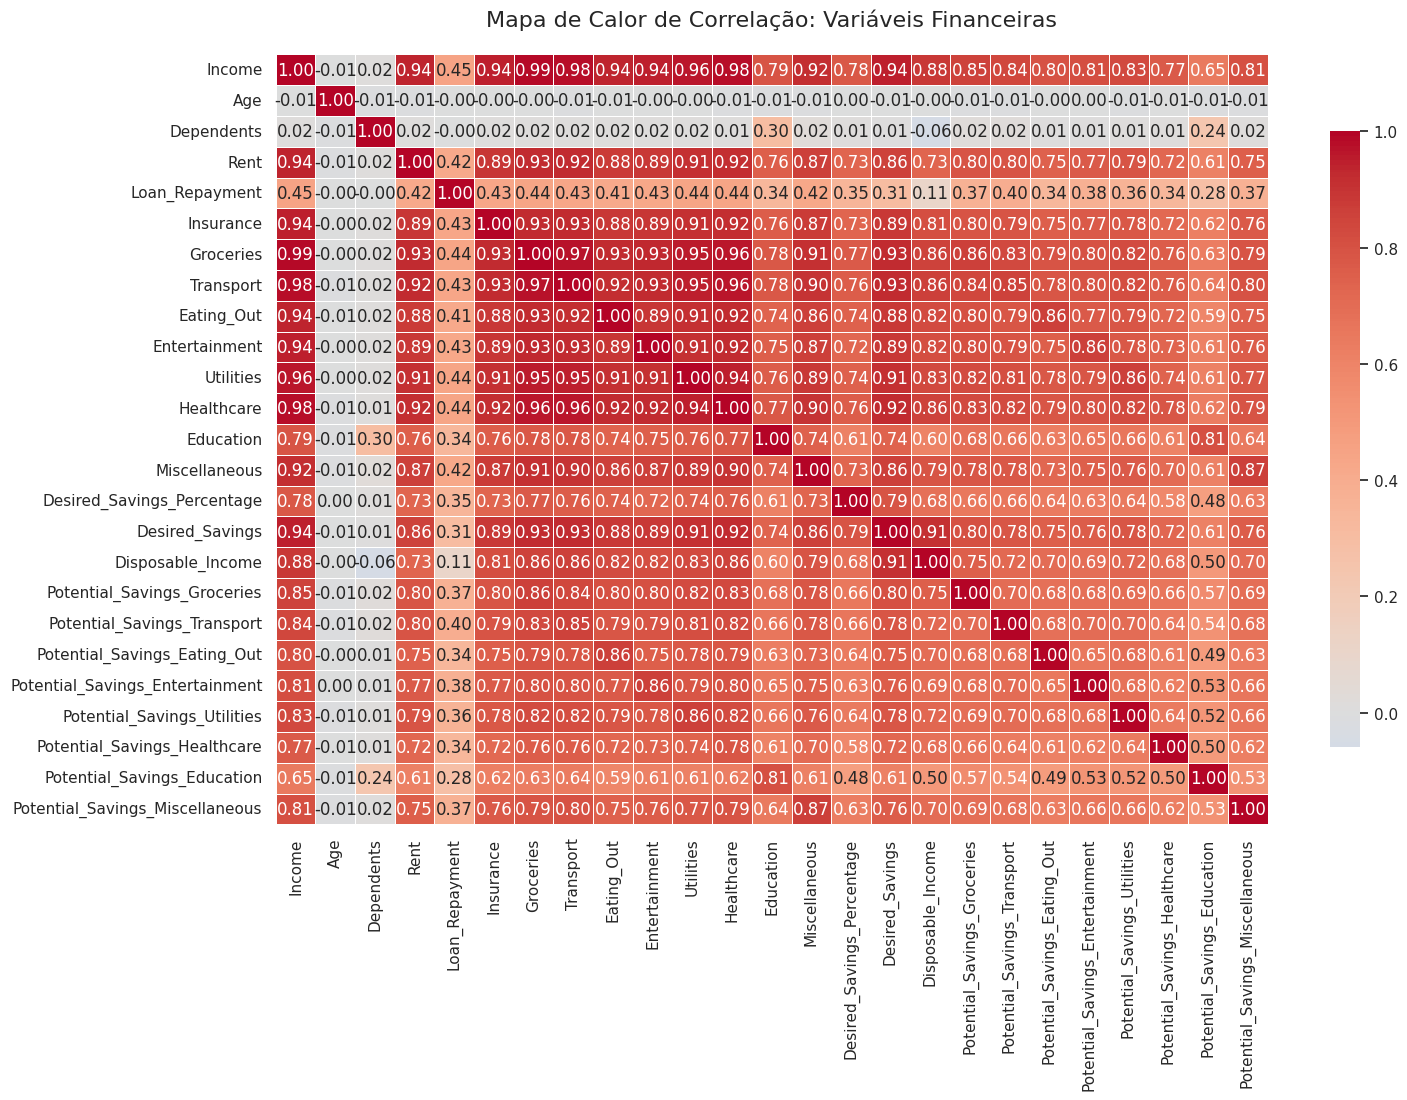

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Selecionando apenas as colunas numéricas relevantes para o heatmap
# Filtramos colunas de metadados ou categorias transformadas se houver
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# 2. Calculando a matriz de correlação
corr_matrix = numeric_df.corr()

# 3. Configurando o gráfico
plt.figure(figsize=(16, 10))
sns.set_theme(style='white')

# Gerando o heatmap com Seaborn
heatmap = sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=.5,
    cbar_kws={'shrink': .8}
)

plt.title('Mapa de Calor de Correlação: Variáveis Financeiras', fontsize=16, pad=20)
plt.show()

### Análise de Insights para Machine Learning

Com base no heatmap gerado, aqui estão os 3 principais pontos de atenção para o desenvolvimento do modelo:

1. **Forte Correlação com Income:** Notamos que gastos fixos e de maior valor (como `Rent` e `Groceries`) costumam apresentar a maior correlação positiva com a `Income`. Isso indica que, à medida que a renda aumenta, o padrão de consumo nessas categorias essenciais sobe proporcionalmente, sendo ótimos preditores de faixa salarial.
2. **Impacto na Disposable_Income:** As variáveis que apresentam correlação negativa com a `Disposable_Income` (como `Loan_Repayment` e `Insurance`) são os principais 'detratores' da saúde financeira. Para o modelo de ML, essas colunas são críticas para prever a capacidade de poupança real do usuário.
3. **Multicolinearidade entre Potential_Savings:** Muitas colunas de `Potential_Savings` apresentam correlação entre si. Para evitar sobreajuste (overfitting) no modelo, pode ser interessante realizar uma seleção de features (Feature Selection) ou usar técnicas de redução de dimensionalidade, focando nas categorias de maior peso como `Groceries` e `Transport`.